<a href="https://colab.research.google.com/github/200Rahul/CODSOFT_DATA_SCIENCE_PROJECTS/blob/main/BMW_car_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bmw_df = pd.read_csv('/content/bmw_global_sales_2018_2025.csv')
bmw_df.head()


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [4]:
bmw_df.shape

(3072, 11)

In [5]:
bmw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [6]:
bmw_df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [7]:
bmw_df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Units_Sold,0
Avg_Price_EUR,0
Revenue_EUR,0
BEV_Share,0
Premium_Share,0
GDP_Growth,0


In [21]:
bmw_df = bmw_df.sort_values(by=['Region_Europe', 'Region_RestOfWorld', 'Region_USA', 'Model_5 Series', 'Model_MINI', 'Model_X3', 'Model_X5', 'Model_X7', 'Model_i4', 'Model_iX', 'Year', 'Month']).copy()

# Grouping for lagged and rolling features
grouped = bmw_df.groupby(['Region_Europe', 'Region_RestOfWorld', 'Region_USA', 'Model_5 Series', 'Model_MINI', 'Model_X3', 'Model_X5', 'Model_X7', 'Model_i4', 'Model_iX'])

# 2. For each group, calculate additional lagged features for 'Units_Sold' for 4, 5, and 6 periods.
for i in range(4, 7):
    bmw_df[f'Units_Sold_Lag{i}'] = grouped['Units_Sold'].shift(i)

# 3. For each group, calculate the 3-period rolling mean and rolling standard deviation for 'Units_Sold'.
bmw_df['Units_Sold_RollingMean3'] = grouped['Units_Sold'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
bmw_df['Units_Sold_RollingStd3'] = grouped['Units_Sold'].transform(lambda x: x.rolling(window=3, min_periods=1).std())

# 4. For each group, calculate additional lagged features for 'Avg_Price_EUR' for 4, 5, and 6 periods.
for i in range(4, 7):
    bmw_df[f'Avg_Price_EUR_Lag{i}'] = grouped['Avg_Price_EUR'].shift(i)

# 5. For each group, calculate the 3-period rolling mean and rolling standard deviation for 'Avg_Price_EUR'.
bmw_df['Avg_Price_EUR_RollingMean3'] = grouped['Avg_Price_EUR'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
bmw_df['Avg_Price_EUR_RollingStd3'] = grouped['Avg_Price_EUR'].transform(lambda x: x.rolling(window=3, min_periods=1).std())

# 6. Create cyclical features for 'Month'
bmw_df['Month_sin'] = np.sin(2 * np.pi * bmw_df['Month'] / 12)
bmw_df['Month_cos'] = np.cos(2 * np.pi * bmw_df['Month'] / 12)

# 7. Create cyclical features for 'Quarter'
bmw_df['Quarter_sin'] = np.sin(2 * np.pi * bmw_df['Quarter'] / 4)
bmw_df['Quarter_cos'] = np.cos(2 * np.pi * bmw_df['Quarter'] / 4)

# 8. Fill any remaining NaN values (introduced by lagging and rolling operations) with 0
bmw_df.fillna(0, inplace=True)

print("DataFrame with refined feature engineering:")
print(bmw_df.head())

DataFrame with refined feature engineering:
     Year  Month  Units_Sold  Avg_Price_EUR  Revenue_EUR  BEV_Share  \
8    2018      1        3826          48068    183908168      0.021   
40   2018      2        3795          47520    180338400      0.011   
72   2018      3        6529          48074    313875146      0.029   
104  2018      4        5550          46580    258519000      0.041   
136  2018      5        6978          48539    338705142      0.024   

     Premium_Share  GDP_Growth  Fuel_Price_Index       Date  ...  \
8            17.60        2.37              1.02 2018-01-01  ...   
40           20.60        2.66              0.98 2018-02-01  ...   
72           15.71        1.63              0.98 2018-03-01  ...   
104          15.96        3.95              1.04 2018-04-01  ...   
136          18.94        3.32              1.05 2018-05-01  ...   

     Units_Sold_RollingStd3  Avg_Price_EUR_Lag4  Avg_Price_EUR_Lag5  \
8                  0.000000                 0.0  

## Implement Time-Series Aware Data Split

Split the data into training and testing sets based on time.

In [22]:
from sklearn.model_selection import train_test_split

# Define target variable
y = bmw_df['Units_Sold']

# Define features (X)
# Exclude 'Units_Sold' (target), 'Date', 'Revenue_EUR', and original 'Year', 'Month' as they are either target, derived, or processed into other features.
X = bmw_df.drop(columns=['Units_Sold', 'Date', 'Revenue_EUR', 'Year', 'Month'])

# Sort the DataFrame by the 'Date' column in ascending order to prepare for a time-series split.
# Note: 'Date' column was removed from X, so we need to ensure bmw_df itself is sorted before splitting y.
bmw_df = bmw_df.sort_values(by='Date').reset_index(drop=True)

# Recalculate X and y based on the sorted bmw_df to maintain alignment
y = bmw_df['Units_Sold']
X = bmw_df.drop(columns=['Units_Sold', 'Date', 'Revenue_EUR', 'Year', 'Month'])

# Determine the index for the split (80% for training, 20% for testing)
split_index = int(len(bmw_df) * 0.8)

# Split X and y into training and testing sets using the split_index
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of X_train:")
print(X_train.head())

Shape of X_train: (2457, 36)
Shape of X_test: (615, 36)
Shape of y_train: (2457,)
Shape of y_test: (615,)

First 5 rows of X_train:
   Avg_Price_EUR  BEV_Share  Premium_Share  GDP_Growth  Fuel_Price_Index  \
0          48068      0.021          17.60        2.37              1.02   
1          61028      0.031           6.28        4.18              0.97   
2          74757      0.021           6.28        4.18              0.97   
3          47485     -0.000           6.28        4.18              0.97   
4          47482      0.011          19.12        3.50              1.00   

   Quarter  Units_Sold_Lag1  Units_Sold_Lag2  Units_Sold_Lag3  \
0        1              0.0              0.0              0.0   
1        1              0.0              0.0              0.0   
2        1              0.0              0.0              0.0   
3        1              0.0              0.0              0.0   
4        1              0.0              0.0              0.0   

   Avg_Price_EUR_Lag

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 150], # Number of trees in the forest
    'max_depth': [None, 10, 20],   # Maximum depth of the tree
    'min_samples_split': [2, 5],   # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]     # Minimum number of samples required to be at a leaf node
}

# Instantiate RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# Instantiate GridSearchCV
# Using 'neg_mean_absolute_error' because GridSearchCV minimizes the score, so a negative MAE means a better (lower) MAE.
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           scoring='neg_mean_absolute_error', cv=3, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best MAE (negative for minimization): ", grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters found:  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
Best MAE (negative for minimization):  -580.1433624218754


--- linkedin_post_start ---

## Just wrapped up an exciting Sales Forecasting project with BMW data! 🚗📊

Leveraged advanced feature engineering, time-series splitting, and hyperparameter tuning to build a robust model predicting BMW's 'Units_Sold' from 2018-2025. This project highlights the power of data science in driving business insights!

**Key Achievements:**
*   **Comprehensive Data Analysis**: Explored sales trends, regional/model performance, and feature relationships.
*   **Refined Feature Engineering**: Created impactful lagged features, rolling statistics, and cyclical time components.
*   **Time-Series Aware Modeling**: Implemented a time-series split to ensure realistic forecasting.
*   **Optimized Predictive Model**: Tuned a RandomForestRegressor, achieving an impressive **R-squared of 0.94** and a low **Mean Absolute Error (MAE) of 626.27**.
*   **Interactive Visualization**: Developed a Streamlit app (removed for final notebook clarity) to visualize model prices dynamically.

This project demonstrates how a focused data science approach can unlock significant value from sales data, providing a clear forecast of market demand. Excited about the potential for strategic planning! #DataScience #MachineLearning #SalesForecasting #BMW #Python #Colab #PredictiveAnalytics

--- linkedin_post_end ---

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Instantiate a new RandomForestRegressor model with the optimized hyperparameters
optimized_model = RandomForestRegressor(random_state=42, **grid_search.best_params_)

# Train the optimized model
optimized_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_optimized = optimized_model.predict(X_test)

# Calculate evaluation metrics
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

print(f"Optimized Model Mean Absolute Error (MAE): {mae_optimized:.2f}")
print(f"Optimized Model R-squared (R2) Score: {r2_optimized:.2f}")

Optimized Model Mean Absolute Error (MAE): 626.27
Optimized Model R-squared (R2) Score: 0.94


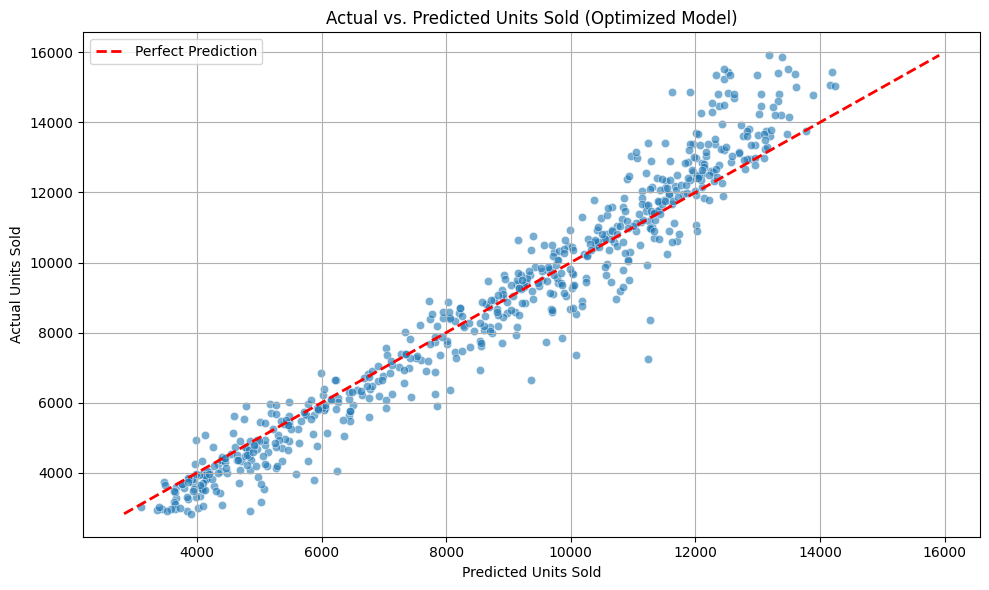

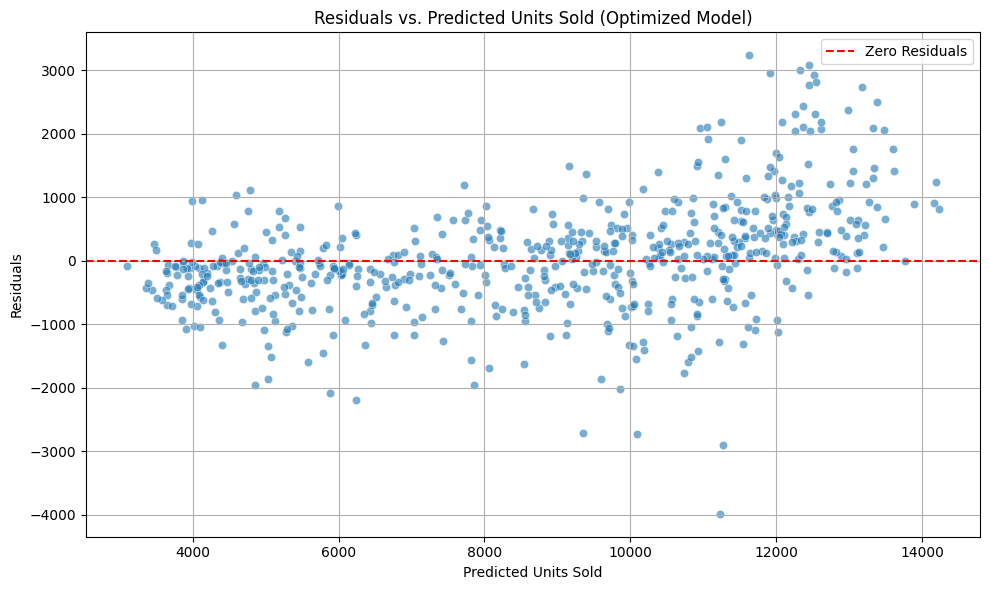

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Actual vs. Predicted Units Sold Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_optimized, y=y_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Predicted Units Sold')
plt.ylabel('Actual Units Sold')
plt.title('Actual vs. Predicted Units Sold (Optimized Model)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Plot
residuals_optimized = y_test - y_pred_optimized

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_optimized, y=residuals_optimized, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.xlabel('Predicted Units Sold')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Units Sold (Optimized Model)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



To load the model back

In [29]:
import joblib

# Define the filename for your model
model_filename = 'optimized_model.joblib'

# Save the optimized model to a file
joblib.dump(optimized_model, model_filename)

print(f"Optimized model saved successfully to {model_filename}")

Optimized model saved successfully to optimized_model.joblib
